In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
import mine_torch

In [4]:
net = nn.Sequential(
    # 这里，我们使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))
device = torch.device('cuda')


X = torch.rand(size=(1, 1, 224, 224), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 96, 54, 54])
ReLU output shape: 	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape: 	 torch.Size([1, 96, 26, 26])
Conv2d output shape: 	 torch.Size([1, 256, 26, 26])
ReLU output shape: 	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape: 	 torch.Size([1, 256, 12, 12])
Conv2d output shape: 	 torch.Size([1, 384, 12, 12])
ReLU output shape: 	 torch.Size([1, 384, 12, 12])
Conv2d output shape: 	 torch.Size([1, 384, 12, 12])
ReLU output shape: 	 torch.Size([1, 384, 12, 12])
Conv2d output shape: 	 torch.Size([1, 256, 12, 12])
ReLU output shape: 	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape: 	 torch.Size([1, 256, 5, 5])
Flatten output shape: 	 torch.Size([1, 6400])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output sh

In [5]:

from ctypes import resize


batch_size=100
trans = torchvision.transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=trans, download=True)

batch_size=100
(train_x,train_y)=mine_torch.batch_data(mnist_train,batch_size,device)
(test_x,test_y)=mine_torch.batch_data(mnist_test,batch_size,device)

test_x.device

TypeError: MNIST.__init__() got an unexpected keyword argument 'resize'

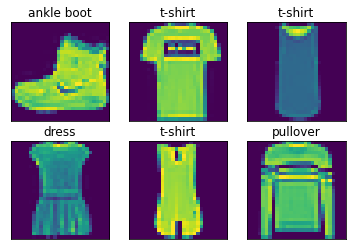

In [ ]:
text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
fig,axes=plt.subplots(2,3)
axes=axes.flatten()#一维
for i in range(6):
    ax=axes[i]
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.imshow(train_x[0][i][0].cpu())
    ax.set_title(text_labels[train_y[0][i].cpu()])
plt.show()#必须放在cpu上

In [ ]:
def calc_acc(X,y,net):
    tot=0
    res=net(X)
    for i in range(X.shape[0]):
        if(res[i].argmax().item()==y[i].item()):
            tot+=1
    return tot/X.shape[0]

In [ ]:
lr=0.9
epoch=25
net.to(device)
net.apply(mine_torch.init_auto)
optimizer=torch.optim.SGD(net.parameters(),lr)
loss=nn.CrossEntropyLoss()

loss_arr,acc_arr=[],[]
net.train()#启用 BatchNormalization 和 Dropout
for i in range(epoch):
    for j in range(batch_size):
        optimizer.zero_grad()
        y_hat=net(train_x[j])
        l=loss(y_hat,train_y[j])
        l.backward()
        optimizer.step()
    if(i%2==0):
        cur_acc=calc_acc(train_x.reshape((-1,1,28,28)),train_y.reshape(-1,1),net)
        print(f'loss= {l:.3f} accuracy={cur_acc:.3f}')        
        loss_arr.append(l)
        acc_arr.append(cur_acc)

loss= 2.302 accuracy=0.100
loss= 1.009 accuracy=0.566
loss= 0.822 accuracy=0.675
loss= 0.675 accuracy=0.723
loss= 0.604 accuracy=0.752
loss= 0.551 accuracy=0.776
loss= 0.506 accuracy=0.795
loss= 0.473 accuracy=0.808
loss= 0.451 accuracy=0.815
loss= 0.433 accuracy=0.824
loss= 0.420 accuracy=0.831
loss= 0.410 accuracy=0.836
loss= 0.402 accuracy=0.841


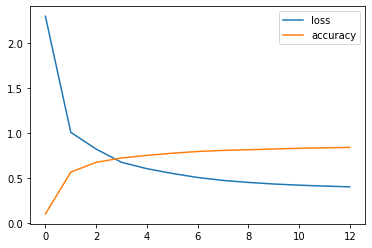

In [ ]:
import numpy as np
fig,ax=plt.subplots(1,1)
for i in range(len(loss_arr)):
    if(isinstance(loss_arr[i],np.ndarray)==False):
        loss_arr[i]=loss_arr[i].to(torch.device('cpu')).detach().numpy()

ax.plot(range(len(loss_arr)),loss_arr)
ax.plot(range(len(loss_arr)),acc_arr)
plt.legend(['loss','accuracy'])
plt.show()

In [ ]:
calc_acc(test_x.reshape((-1,1,28,28)),test_y.reshape(-1,1),net)

0.8267